In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
# Raw data access

import os
os.chdir('/content/drive/MyDrive/MPXV_pycaret/NEW_ML_MPXV')

#### **Importing the modules** ####

In [50]:
from glob import glob
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [51]:
ls


 13_3X1_K_C_ex_run.csv                                                  27_micro_F_P_1_run.csv
 13_K_C_ex_run.csv                                                      27_micro_P_1_run.csv
 13_K_C_MPXV_Marker_Prediction_Using_Classification_Pycrate.ipynb       feature_importance_1.pdf
 13_py_rna_gini.png                                                     feature_importance.pdf
 27_F_M_K_C_MPXV_Marker_Prediction_Using_Classification_Pycrate.ipynb  'Feature Importance.pdf'
 27_K_C_run.csv                                                         logs.log
 27_K_run.csv


#### **Load Dataset** ####

In [52]:
MPXV_df = pd.read_csv("27_micro_P_1_run.csv", index_col=0)
#MPXV_df = pd.read_csv("27_micro_F_P_1_run.csv", index_col=0)
#MPXV_df = pd.read_csv("27_K_run.csv", index_col=0)
#MPXV_df = pd.read_csv("27_K_C_run.csv", index_col=0)



In [53]:
display(MPXV_df.head())


,ATP1B3,ATP5F1B,BSG,GATA6,GM2A,IDH2,INHBA,ITGB6,NEFM,CNOT4,...,TUBA1B,ATP5MG,NFAT5,OGFR,WDR37,CBX6,CLDN15,UBXN7,FGFR1OP2,condition
ID,,,,,,,,,,,,,,,,,,,,,
GSM283161,4.014948,0.184752,1.159737,-3.077378,-0.506100,0.365488,-0.174623,-0.229117,0.060475,1.660946,...,0.732012,-0.831003,-2.905206,0.818793,0.965282,1.173491,1.501442,0.408193,-0.951501,0
GSM283162,4.201607,-0.108550,2.090219,-3.516819,-1.223226,0.797619,0.055160,0.051314,-0.147098,-1.309504,...,1.246404,-0.460002,NaN,0.189006,0.652313,1.288309,0.562620,-0.067151,-1.195227,0
GSM283163,3.487499,-0.469927,1.240104,-2.880897,-0.940641,-0.457340,1.323238,-0.117473,-0.336323,1.607633,...,0.607491,-0.248685,-3.991118,0.685589,1.092964,1.698321,1.881233,-0.684744,-0.582660,0
GSM283164,3.536909,-0.740355,2.493463,-3.330733,-0.919210,-0.146549,0.398619,-0.020508,0.367363,1.163635,...,1.546333,0.420983,-3.036887,-0.097539,0.205829,1.178466,0.110225,-0.067137,-1.101887,0
GSM283165,3.760728,-0.416258,-0.389859,0.466439,2.307402,0.827271,0.295568,0.501859,-0.121612,-0.146908,...,1.386412,-1.844663,0.564693,-0.598033,-1.798006,-0.247699,-0.720121,0.002475,0.113217,0


#### **Data Preprocessing** ####
##### **Checking null entries** #####

In [54]:
MPXV_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124 entries, GSM283161 to GSM283416
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ATP1B3     124 non-null    float64
 1   ATP5F1B    123 non-null    float64
 2   BSG        122 non-null    float64
 3   GATA6      121 non-null    float64
 4   GM2A       123 non-null    float64
 5   IDH2       124 non-null    float64
 6   INHBA      122 non-null    float64
 7   ITGB6      124 non-null    float64
 8   NEFM       123 non-null    float64
 9   CNOT4      124 non-null    float64
 10  OVGP1      123 non-null    float64
 11  PLAGL1     122 non-null    float64
 12  SLC8A2     120 non-null    float64
 13  ICAM5      122 non-null    float64
 14  XRCC4      124 non-null    float64
 15  ZNF212     123 non-null    float64
 16  ELL        124 non-null    float64
 17  DHX38      122 non-null    float64
 18  TUBA1B     124 non-null    float64
 19  ATP5MG     124 non-null    float64
 20  N

In [55]:
# Checking columns having null values
#MPXV_df.isna().sum()

In [56]:
# Getting the list of columns having missing values
#x = dengue_features.columns[dengue_features.isna().sum() > 0].tolist()
#x

In [57]:
# Filling the missing value with mean
#for i in x:
#    dengue_features[i] = dengue_features[i].fillna(dengue_features[i].mean())
#dengue_features.head()

##### **merge dataset** #####

In [58]:
# Adding total cases
#dengue_features['total_cases'] = dengue_labels['total_cases']
#dengue_features.head(3)

##### **Feature Engineering** #####
The dengue cases of San Juan sj and Iquitos iq are not dependent. So splitting them into different DataFrames

In [59]:
#X_sj = dengue_features[dengue_features['city'] == 'sj']
#X_iq = dengue_features[dengue_features['city'] == 'iq']

In [60]:
# MPXV_df = MPXV_df.drop(['condition'], axis=1)
#X_iq = X_iq.drop(['city', 'weekofyear', 'week_start_date'], axis=1)

In [61]:
# display(MPXV_df.head(2))
#display(X_iq.head(2))

In [62]:
#display(X_sj.head(2))
#display(X_iq.head(2))

##### **Changing the order of columns in X_sj and X_iq DataFrames** #####

In [63]:
# X_sj.columns

In [64]:
# X_sj_1 = X_sj.columns[-3:].values.tolist()
# X_sj_2 = X_sj.columns[:15].values.tolist()

In [65]:
# print(X_sj_1)

In [66]:
# years = X_sj_1 + X_sj_2
# print(years)

In [67]:
# X_sj = X_sj[years[::-1]].join(X_sj[X_sj.columns[:24]])
# X_sj.head(100)

In [68]:
# years = X_iq.columns[:23:-1].values.tolist()
# print(years)
# X_iq = X_iq[years[::-1]].join(X_iq[X_iq.columns[:24]])
# X_iq.head()

In [69]:
# Removing dummy variable trap
# X_sj = X_sj.drop(1990, axis=1)
# X_iq = X_iq.drop(2000, axis=1)

In [70]:
# x_sj_arr = X_sj.iloc[:].values
# x_iq_arr = X_iq.iloc[:].values

In [71]:
# y_sj = X_sj['total_cases'].values
# y_iq = X_iq['total_cases'].values

In [72]:
# X_sj = X_sj.drop('total_cases', axis=1).values
# X_iq = X_iq.drop('total_cases', axis=1).values

#### **Splitting the dataframes into train and test** ####

In [73]:
!pip install pycaret

In [74]:
# import pycaret classification and init setup
from pycaret.classification import *
setup(MPXV_df, target = 'condition', train_size = 0.8, session_id = 123)
# setup(X_iq, target = 'total_cases', train_size = 0.8, session_id = 123)

,Description,Value
0,Session id,123
1,Target,condition
2,Target type,Binary
3,Original data shape,"(124, 28)"
4,Transformed data shape,"(124, 28)"
5,Transformed train set shape,"(99, 28)"
6,Transformed test set shape,"(25, 28)"
7,Numeric features,27
8,Rows with missing values,17.7%
9,Preprocess,True


In [75]:
import pycaret
print(pycaret.__version__)


3.3.2


## **Compare Models** ##

In [76]:
# compare baseline models
best = compare_models()
print(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9500,0.9281,0.7500,1.0000,0.8333,0.8077,0.8333,0.4330
et,Extra Trees Classifier,0.9500,0.9625,0.7500,1.0000,0.8333,0.8077,0.8333,0.1590
lightgbm,Light Gradient Boosting Machine,0.9500,0.9062,0.8000,0.9667,0.8467,0.8198,0.8430,0.5820
knn,K Neighbors Classifier,0.9400,0.9250,0.7500,0.9500,0.8167,0.7837,0.8042,0.0820
xgboost,Extreme Gradient Boosting,0.9289,0.9031,0.7500,0.9000,0.7833,0.7445,0.7703,0.0760
ada,Ada Boost Classifier,0.9200,0.8875,0.7500,0.8833,0.7767,0.7310,0.7569,0.2470
gbc,Gradient Boosting Classifier,0.9189,0.9094,0.7500,0.8833,0.7733,0.7281,0.7546,0.1950
ridge,Ridge Classifier,0.9089,0.9125,0.7500,0.8333,0.7433,0.6919,0.7231,0.0580
lr,Logistic Regression,0.8989,0.9250,0.7000,0.8167,0.7133,0.6557,0.6842,1.2980
dt,Decision Tree Classifier,0.8978,0.8438,0.7500,0.7833,0.7333,0.6756,0.6958,0.0620


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


## **Create Model**##

In [77]:
# create model
ada = create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9000,0.8125,0.5000,1.0000,0.6667,0.6154,0.6667
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,0.9000,1.0000,0.5000,1.0000,0.6667,0.6154,0.6667
6,0.9000,0.9688,0.5000,1.0000,0.6667,0.6154,0.6667
7,0.9000,1.0000,0.5000,1.0000,0.6667,0.6154,0.6667
8,0.9000,0.5000,0.5000,1.0000,0.6667,0.6154,0.6667


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [78]:
# print model parameters
print(ada)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


## **Tune Model** ##

In [79]:
# tune hyperparameters of et
tuned_ada = tune_model(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9000,0.5625,0.5000,1.0000,0.6667,0.6154,0.6667
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9000,1.0000,1.0000,0.6667,0.8000,0.7368,0.7638
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,0.9000,0.9375,0.5000,1.0000,0.6667,0.6154,0.6667
7,0.8000,0.9375,0.5000,0.5000,0.5000,0.3750,0.3750
8,0.9000,0.5625,0.5000,1.0000,0.6667,0.6154,0.6667


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [80]:
# print tuned model
print(tuned_ada)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


In [81]:
tuned_ada

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)

In [82]:
# to access the tuner object you can set return_tuner = True
tuned_ada, tuner = tune_model(ada, return_tuner=True)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9000,0.5625,0.5000,1.0000,0.6667,0.6154,0.6667
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9000,1.0000,1.0000,0.6667,0.8000,0.7368,0.7638
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,0.9000,0.9375,0.5000,1.0000,0.6667,0.6154,0.6667
7,0.8000,0.9375,0.5000,0.5000,0.5000,0.3750,0.3750
8,0.9000,0.5625,0.5000,1.0000,0.6667,0.6154,0.6667


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [83]:
tuner

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=False),
                   error_score=nan,
                   estimator=Pipeline(memory=Memory(location=None),
                                      steps=[('numerical_imputer',
                                              TransformerWrapper(exclude=None,
                                                                 include=['ATP1B3',
                                                                          'ATP5F1B',
                                                                          'BSG',
                                                                          'GATA6',
                                                                          'GM2A',
                                                                          'IDH2',
                                                                          'INHBA',
                                                                          'ITGB6',
                                                                          'NEFM',
                                                                          'CNOT4',
                                                                          'OVGP1',
                                                                          'PLAGL1',
                                                                          'SLC8A2',
                                                                          'ICAM5',
                                                                          'XRCC4',
                                                                          'ZNF212',
                                                                          'ELL'...
                                        'actual_estimator__min_samples_leaf': [2,
                                                                               3,
                                                                               4,
                                                                               5,
                                                                               6],
                                        'actual_estimator__min_samples_split': [2,
                                                                                5,
                                                                                7,
                                                                                9,
                                                                                10],
                                        'actual_estimator__n_estimators': [10,
                                                                           20,
                                                                           30,
                                                                           40,
                                                                           50,
                                                                           60,
                                                                           70,
                                                                           80,
                                                                           90,
                                                                           100,
                                                                           110,
                                                                           120,
                                                                           130,
                                                                           140,
                                                                           150,
                                                                           160,
                                                                           170,
                                                                         

## **Analyze Model** ##

In [84]:
#plot_model(rf, plot = 'residuals')

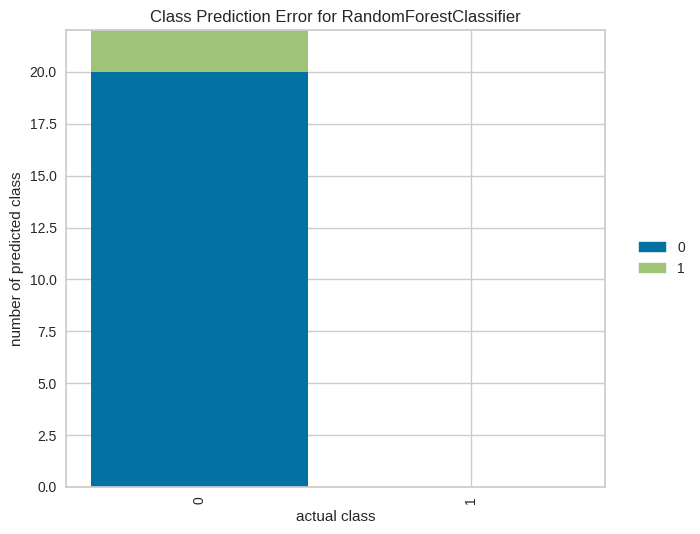

In [85]:
# predicting error plot
plot_model(ada, plot = 'error')

In [86]:
# cooks distance plot
#plot_model(rf, plot = 'cooks')

In [87]:
# recursive feature elemination
#plot_model(ada, plot = 'rfe')

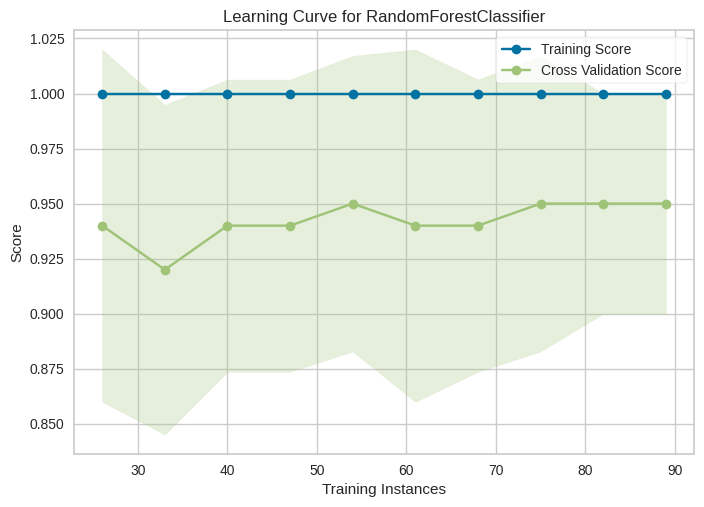

In [88]:
# learning curve
plot_model(ada, plot = 'learning')

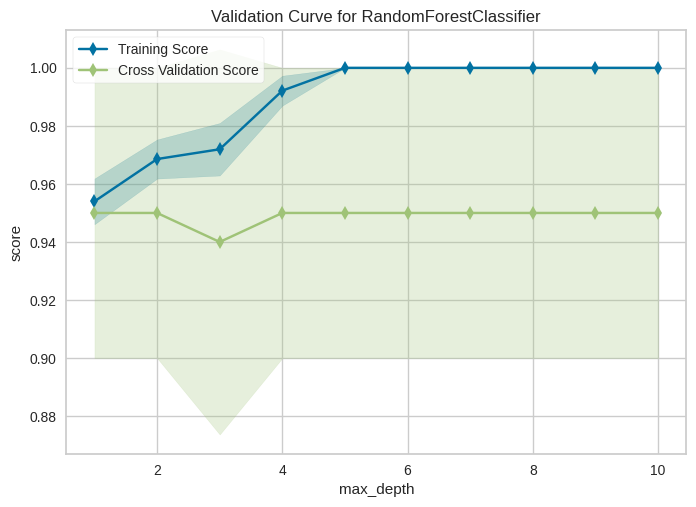

In [89]:
# validation curve
plot_model(ada, plot = 'vc')

In [90]:
# manifold learning plot
#plot_model(rf, plot = 'manifold')

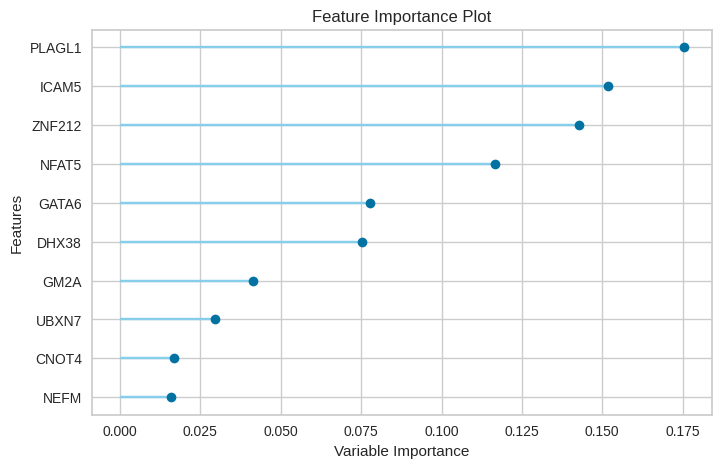

In [91]:
# plot feature importance
plot_model(ada, plot = 'feature')

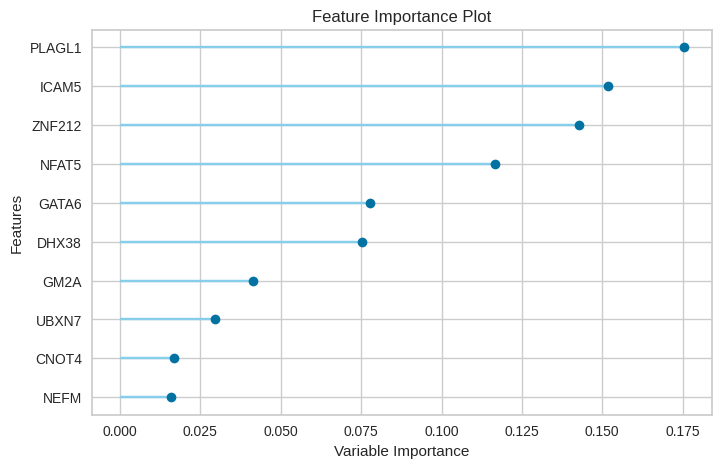

In [92]:
from pycaret.classification import setup, compare_models, create_model, plot_model
import matplotlib.pyplot as plt

# Example data setup (replace with your actual data setup)
# data = ... (load your dataset)
# clf = setup(data, target='target_column')

# Example model creation (replace 'ada' with your actual model)
# ada = create_model('ada')
# Generate the feature importance plot
plot_model(ada, plot='feature')

# Ensure the plot is rendered
plt.gcf().canvas.draw()

# Save the plot as a PDF file
plt.savefig('feature_importance_1.pdf')

# Close the plot window if running interactively
plt.close()


## **Evaluate Model** ##

In [93]:
# evaluate model
evaluate_model(rf)

NameError: name 'rf' is not defined

## **Finalize Model** ##

In [ ]:
# finalize a model
finalize_model(rf)

## **Prediction** ##

In [ ]:
# predict on test set
holdout_pred = predict_model(rf)